### **Imports**

In [411]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from typing import Dict, List, Literal, Tuple, Type

### **Load data**

#### Breast cancer *(used in Task 5)*

In [412]:
cancer_data = load_breast_cancer()

### **Task 1**

#### Basic operations with PyTorch

In [413]:
# 1. Tensor Creation
tensor_a: torch.Tensor = torch.tensor([[1, 2, 3], [4, 5, 6]])
tensor_b: torch.Tensor = torch.tensor([[7, 8, 9], [10, 11, 12]])

print(f"Tensor A:\n{tensor_a}")
print(f"Tensor B:\n{tensor_b}\n")

# 2. Addition
sum_result: torch.Tensor = tensor_a + tensor_b
print(f"Sum (A + B):\n{sum_result}\n")

# 3. Element-wise Multiplication (Hadamard product)
element_mul_result: torch.Tensor = tensor_a * tensor_b
print(f"Element-wise Multiplication (A * B):\n{element_mul_result}\n")

# 4. Transposition
transposed_a: torch.Tensor = tensor_a.T
print(f"Transposed Tensor A (Shape: {transposed_a.shape}):\n{transposed_a}\n")

# 5. Matrix Multiplication
# We use the transposed version of B to match dimensions for multiplication.
matmul_result: torch.Tensor = torch.matmul(tensor_a, tensor_b.T)
print(f"Matrix Multiplication (A @ B.T):\n{matmul_result}")

Tensor A:
tensor([[1, 2, 3],
        [4, 5, 6]])
Tensor B:
tensor([[ 7,  8,  9],
        [10, 11, 12]])

Sum (A + B):
tensor([[ 8, 10, 12],
        [14, 16, 18]])

Element-wise Multiplication (A * B):
tensor([[ 7, 16, 27],
        [40, 55, 72]])

Transposed Tensor A (Shape: torch.Size([3, 2])):
tensor([[1, 4],
        [2, 5],
        [3, 6]])

Matrix Multiplication (A @ B.T):
tensor([[ 50,  68],
        [122, 167]])


### **Task 2**

#### Simple ANN model

In [414]:
class SimpleANN(nn.Module):
    """
    A versatile Artificial Neural Network capable of handling both 
    regression and binary classification tasks.
    
    Architecture:
        Input -> Hidden (ReLU) -> Output (Optional: Sigmoid)
    """
    
    def __init__(self, input_size: int, hidden_size: int, output_size: int, 
                 task_type: Literal['regression', 'classification'] = 'regression') -> None:
        """
        Args:
            input_size (int): Number of input features.
            hidden_size (int): Number of neurons in the hidden layer.
            output_size (int): Number of output neurons.
            task_type (str): 'regression' (linear output) or 'classification' (sigmoid output).
        """
        super(SimpleANN, self).__init__()
        
        self.task_type = task_type
        
        # Linear layer: Input -> Hidden
        self.hidden_layer = nn.Linear(input_size, hidden_size)
        
        # Activation for hidden layer
        self.activation = nn.ReLU()
        
        # Linear layer: Hidden -> Output
        self.output_layer = nn.Linear(hidden_size, output_size)
        
        # Activation for output layer (only for classification)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass defining the data flow.
        """
        x = self.hidden_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        
        # Apply Sigmoid only if we are doing classification to squash output to [0, 1]
        if self.task_type == 'classification':
            x = self.sigmoid(x)
            
        return x

In [415]:
# Data Preparation
# Training data: range [-10, 10]
X_train_np = np.linspace(-10, 10, 100)
X_train = torch.tensor(X_train_np, dtype=torch.float32).view(-1, 1)
y_train = 2 * X_train + 1

In [416]:
# Model Training
model = SimpleANN(input_size=1, hidden_size=10, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epochs = 500
for epoch in range(epochs):
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"Final Training Loss: {loss.item():.4f}")

Final Training Loss: 0.0030


In [417]:
# Evaluation
# Switch model to evaluation mode
model.eval()

# Generate Test Data: Wider range [-15, 15] to check extrapolation
X_test_np = np.linspace(-15, 15, 150)
X_test = torch.tensor(X_test_np, dtype=torch.float32).view(-1, 1)

# Calculate True Values for comparison
y_test_actual = 2 * X_test + 1

# Perform inference without gradient calculation (saves memory)
with torch.no_grad():
    y_test_pred = model(X_test)

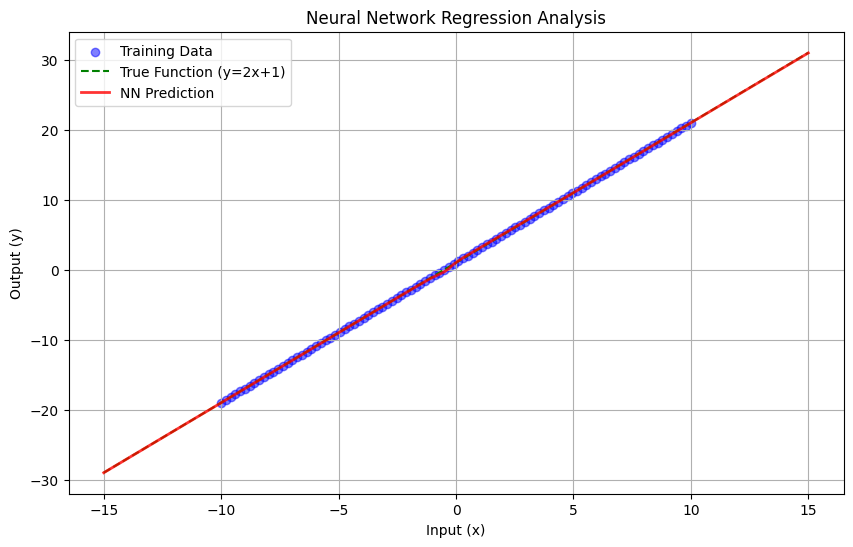

In [418]:
# Plotting results
plt.figure(figsize=(10, 6))

# Plot 1: The training data points the model saw
plt.scatter(X_train.numpy(), y_train.numpy(), color='blue', alpha=0.5, label='Training Data')

# Plot 2: The actual mathematical function (Ground Truth)
plt.plot(X_test.numpy(), y_test_actual.numpy(), color='green', linestyle='--', label='True Function (y=2x+1)')

# Plot 3: What the Neural Network predicts
plt.plot(X_test.numpy(), y_test_pred.numpy(), color='red', alpha=0.8, linewidth=2, label='NN Prediction')

plt.title('Neural Network Regression Analysis')
plt.xlabel('Input (x)')
plt.ylabel('Output (y)')
plt.legend()
plt.grid(True)
plt.show()

### **Task 3**

#### Comparison of different activation functions

In [419]:
# Setting seed for fairness in comparison
torch.manual_seed(42)

class ConfigurableANN(nn.Module):
    """
    ANN model that accepts a specific activation function for the hidden layer.
    """
    def __init__(self, activation_fn: nn.Module) -> None:
        """
        Args:
            activation_fn (nn.Module): The activation function layer (e.g., nn.ReLU()).
        """
        super(ConfigurableANN, self).__init__()
        # Input: 1 -> Hidden: 20 (Increased size to allow complex approximations)
        self.hidden_layer = nn.Linear(1, 20)
        self.activation = activation_fn
        # Hidden: 20 -> Output: 1
        self.output_layer = nn.Linear(20, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.hidden_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)
        return x

In [420]:
def get_data() -> tuple[torch.Tensor, torch.Tensor]:
    """Generates synthetic linear data: y = 2x + 1"""
    X_np = np.linspace(-5, 5, 100)
    X = torch.tensor(X_np, dtype=torch.float32).view(-1, 1)
    y = 2 * X + 1
    return X, y

def train_model(activation_name: str, activation_fn: nn.Module, X: torch.Tensor, y: torch.Tensor) -> List[float]:
    """
    Trains a model with a specific activation function and returns the loss history.
    """
    # Initialize model with the chosen activation
    model = ConfigurableANN(activation_fn)
    
    criterion = nn.MSELoss()
    # Use Adam optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.01) 
    
    loss_history = []
    epochs = 300
    
    print(f"Training with {activation_name}...")
    
    for _ in range(epochs):
        predictions = model(X)
        loss = criterion(predictions, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())
        
    return loss_history

In [421]:
def activation_functions_comparison() -> None:
    """
    Runs the training loop for multiple activation functions and plots the comparison.
    """
    X, y = get_data()
    
    # Dictionary mapping names to PyTorch activation modules
    activations = {
        "ReLU": nn.ReLU(),
        "Sigmoid": nn.Sigmoid(),
        "Tanh": nn.Tanh()
    }
    
    results: Dict[str, List[float]] = {}
    
    # Run training for each activation type
    for name, func in activations.items():
        # Reset seed for each loop to ensure weights initialize identically 
        # (mostly) for fair comparison of the activation function itself.
        torch.manual_seed(42) 
        results[name] = train_model(name, func, X, y)

    # Visualization
    plt.figure(figsize=(10, 6))
    
    for name, losses in results.items():
        plt.plot(losses, label=f'{name} Activation')
        
    plt.title('Training Loss Comparison: ReLU vs Sigmoid vs Tanh')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.yscale('log') # Log scale allows seeing small differences better
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha = 0.4)
    plt.show()

Training with ReLU...
Training with Sigmoid...
Training with Tanh...


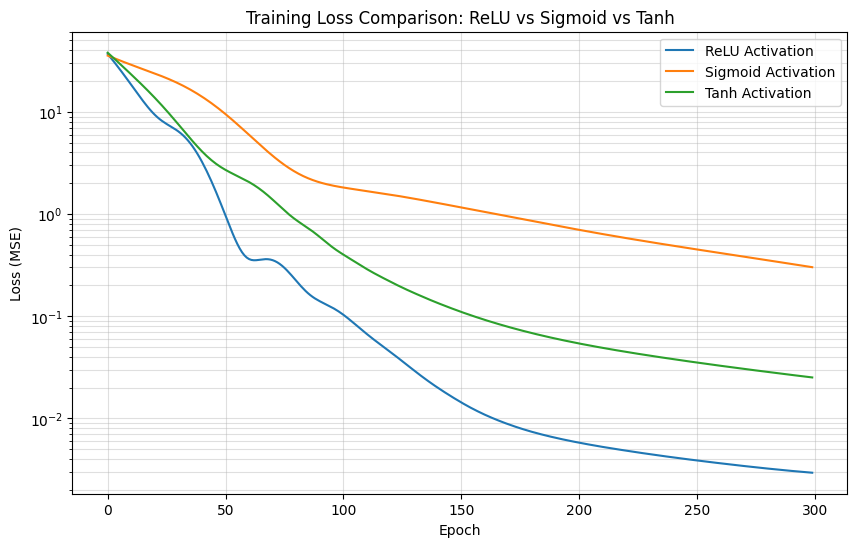

In [422]:
activation_functions_comparison()

#### **Conclusions:**

#### ReLU: Demonstrates the best performance. It has the fastest convergence rate (steepest drop in loss) and achieves the lowest final Mean Squared Error (orders of magnitude lower than the others). This suggests that ReLU effectively prevents the vanishing gradient problem in this context, allowing the model to learn the linear relationship y=2x+1 preciseley.

#### Tanh: Shows moderate performance. While the loss decreases steadily, the convergence is significantly slower than ReLU. The model learns, but it requires more epochs to reach a comparable error rate.

#### Sigmoid: Exhibits the worst performance. The curve is very shallow, indicating slow learning. The final loss remains relatively high.

### **Task 4**

In [423]:
def get_regression_data() -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Generates synthetic data for regression: y = 2x + 1 with noise.
    """
    # Create 200 points between -5 and 5
    X = torch.linspace(-5, 5, 200).view(-1, 1)
    # y = 2x + 1 + Gaussian Noise
    y = 2 * X + 1 + torch.randn(X.size()) * 0.5
    return X, y

def get_classification_data() -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Generates synthetic data for binary classification.
    Class 0 if x <= 0, Class 1 if x > 0.
    """
    X = torch.linspace(-5, 5, 200).view(-1, 1)
    # Target is 1.0 where X > 0, else 0.0
    y = (X > 0).float()
    return X, y

In [424]:
def train_and_track(
    task_type: str,
    optimizer_class: Type[optim.Optimizer],
    learning_rate: float,
    X: torch.Tensor,
    y: torch.Tensor
) -> List[float]:
    """
    Initializes a fresh model, trains it, and returns the list of loss values per epoch.
    """
    # 1. Initialize the model (using SimpleANN class)
    # We use fixed random seed for fair comparison between optimizers
    torch.manual_seed(42)
    model = SimpleANN(input_size=1, hidden_size=20, output_size=1, task_type=task_type)
    
    # 2. Select Loss Function based on task
    if task_type == 'regression':
        criterion = nn.MSELoss()
    else:
        # Binary Cross Entropy for classification
        criterion = nn.BCELoss()
        
    # 3. Initialize Optimizer (SGD or Adam)
    optimizer = optimizer_class(model.parameters(), lr=learning_rate)
    
    loss_history = []
    epochs = 200
    
    # 4. Training Loop
    for _ in range(epochs):
        predictions = model(X)
        loss = criterion(predictions, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())
        
    return loss_history

In [425]:
def run_SGD_Adam_comparison() -> None:
    """
    Orchestrates the comparative experiment between SGD and Adam optimizers
    for both regression and classification tasks.

    The function performs the following steps:
    1. Generates synthetic datasets for regression and binary classification.
    2. Trains the SimpleANN model using both SGD and Adam optimizers for each task.
    3. Visualizes the training loss history in a dual-subplot figure to demonstrate
       convergence speed and stability differences.
    """
    # 1. Prepare Data
    X_reg, y_reg = get_regression_data()
    X_cls, y_cls = get_classification_data()
    
    # Compare SGD vs Adam for Regression
    loss_reg_sgd = train_and_track('regression', optim.SGD, 0.01, X_reg, y_reg)
    loss_reg_adam = train_and_track('regression', optim.Adam, 0.01, X_reg, y_reg)
    
    # Compare SGD vs Adam for Classification
    loss_cls_sgd = train_and_track('classification', optim.SGD, 0.01, X_cls, y_cls)
    loss_cls_adam = train_and_track('classification', optim.Adam, 0.01, X_cls, y_cls)
    
    # 2. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot Regression Comparison
    ax1.plot(loss_reg_sgd, label='SGD', color='orange')
    ax1.plot(loss_reg_adam, label='Adam', linewidth=2, color='blue')
    ax1.set_title('Regression (MSE Loss)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot Classification Comparison
    ax2.plot(loss_cls_sgd, label='SGD', color='orange')
    ax2.plot(loss_cls_adam, label='Adam', linewidth=2, color='blue')
    ax2.set_title('Classification (BCE Loss)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

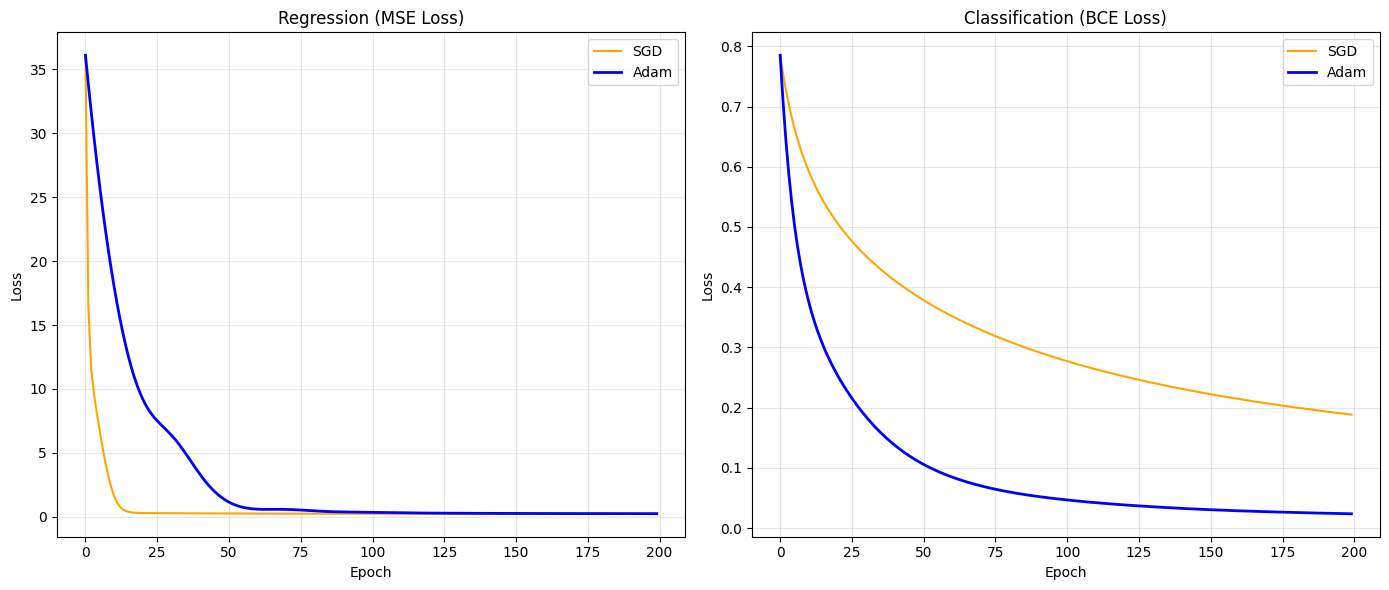

In [426]:
run_SGD_Adam_comparison()

#### **Cocnlusions:**<br> Regression: SGD converged faster than Adam for this simple linear problem, dropping to near-zero loss almost instantly. Adam took slightly longer to settle.<br> Classification: Adam demonstrated superior performance, reducing the error much more rapidly than SGD, which showed a slow, gradual descent.

### **Task 5**

#### ANN training on the Breast Cancer dataset

In [427]:
# Use breast cancer dataset
X, y = cancer_data.data, cancer_data.target
    
# Split Data (80% train, 20% test)
# stratify=y ensures both classes are represented equally in train/test splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization
# Scales data to have mean=0 and variance=1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # We use the scaler fitted on train data

# Convert to Tensors
# Float32 is standard for PyTorch weights
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# Reshape targets to (N, 1) to match output layer shape
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [428]:
def train_breast_cancer_model(
    X_train: torch.Tensor, 
    X_test: torch.Tensor, 
    y_train: torch.Tensor, 
    y_test: torch.Tensor
) -> None:
    """
    Trains the SimpleANN model on the provided Breast Cancer dataset tensors,
    evaluates its accuracy, and plots a Confusion Matrix.

    Args:
        X_train (torch.Tensor): Training features tensor of shape (N_train, num_features).
        X_test (torch.Tensor): Test features tensor of shape (N_test, num_features).
        y_train (torch.Tensor): Training targets tensor of shape (N_train, 1).
        y_test (torch.Tensor): Test targets tensor of shape (N_test, 1).
    """
    
    input_dim = X_train.shape[1]
    
    # Initialize Model
    model = SimpleANN(input_size=input_dim, hidden_size=64, output_size=1, task_type='classification')
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    print(f"Training on {input_dim} features.")
    
    # Training Loop
    epochs = 100
    for _ in range(epochs):
        model.train()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluation Phase 
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        # Convert probabilities to binary classes (0 or 1)
        predicted_classes = (test_predictions > 0.5).float()
        
        # Calculate Accuracy
        correct = (predicted_classes == y_test).float().sum()
        accuracy = correct / y_test.shape[0]
        
        print("\nEvaluation Results ")
        print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")
        
        # Confusion Matrix Visualization 
        # Convert to numpy for sklearn/seaborn
        y_true_np = y_test.numpy()
        y_pred_np = predicted_classes.numpy()
    
        cm = confusion_matrix(y_true_np, y_pred_np)
        
        # Plotting using Seaborn
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Malignant (0)', 'Benign (1)'],
                    yticklabels=['Malignant (0)', 'Benign (1)'])
        
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

Training on 30 features.

Evaluation Results 
Test Accuracy: 94.74%


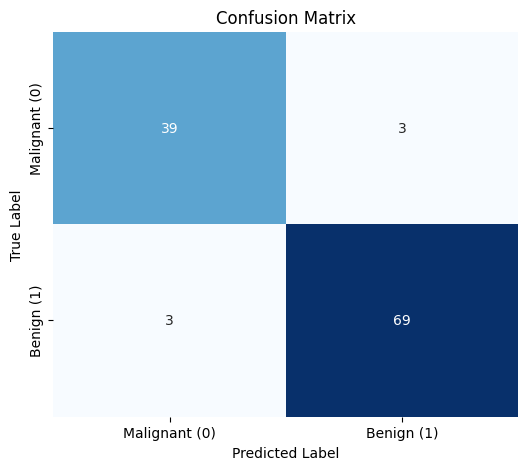

In [429]:
train_breast_cancer_model(X_train, X_test, y_train, y_test)

#### **Conclusion**: The model performed well, but cases classified as benign that are actually malignant are particularly dangerous.

### **Task 6**

#### Overfitting and regularization techniques

In [430]:
# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

class RegularizedANN(nn.Module):
    """
    ANN with Dropout support to demonstrate regularization.
    """
    def __init__(self, input_size: int, hidden_size: int, output_size: int, dropout_rate: float = 0.0) -> None:
        """
        Args:
            dropout_rate (float): Probability of an element to be zeroed (0.0 means no dropout).
        """
        super(RegularizedANN, self).__init__()
        
        self.hidden_layer = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU()
        
        # Dropout layer - active only during training
        self.dropout = nn.Dropout(p=dropout_rate)
        
        self.output_layer = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.hidden_layer(x)
        x = self.activation(x)
        x = self.dropout(x) # Apply dropout after activation
        x = self.output_layer(x)
        x = self.sigmoid(x)
        return x

In [431]:
# Data Preparation (Imbalanced to force overfitting potential)
def get_data() -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    data = load_breast_cancer()
    X, y = data.data, data.target
    # Small train set (15%) to make regularization important
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.85, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    return (torch.tensor(X_train, dtype=torch.float32), 
            torch.tensor(X_test, dtype=torch.float32), 
            torch.tensor(y_train, dtype=torch.float32).view(-1, 1), 
            torch.tensor(y_test, dtype=torch.float32).view(-1, 1))

In [432]:
# Single Training Run
def evaluate_config(
    dropout: float, 
    l2: float, 
    X_train: torch.Tensor, y_train: torch.Tensor,
    X_test: torch.Tensor, y_test: torch.Tensor
) -> float:
    """
    Trains a model with specific hyperparameters and returns validation accuracy.
    """
    input_dim = X_train.shape[1]
    # Large hidden size to allow overfitting
    model = RegularizedANN(input_dim, hidden_size=128, output_size=1, dropout_rate=dropout)
    
    criterion = nn.BCELoss()
    # Weight_decay is the L2 parameter
    optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=l2)
    
    epochs = 200
    
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        
    # Final Evaluation
    model.eval()
    with torch.no_grad():
        preds = model(X_test)
        predicted_classes = (preds > 0.5).float()
        correct = (predicted_classes == y_test).float().sum()
        accuracy = correct / y_test.shape[0]
        
    return accuracy.item()

In [433]:
# Grid Search Runner
def run_hyperparameter_search() -> None:
    X_train, X_test, y_train, y_test = get_data()
    
    # Define the Grid
    dropout_values = [0.0, 0.5, 0.8, 0.9, 0.95, 0.99]
    l2_values = [0.0, 0.0001, 0.001, 0.01, 0.1, 0.15]
    
    results = []
    
    print(f"Starting Grid Search on {len(dropout_values) * len(l2_values)} combinations...")
    
    # Iterate through all combinations
    for drop in dropout_values:
        row_results = []
        for l2 in l2_values:
            # We reset seed slightly to allow variation but keep comparison fair
            torch.manual_seed(42) 
            
            acc = evaluate_config(drop, l2, X_train, y_train, X_test, y_test)
            
            # Save for DataFrame/Heatmap
            results.append({
                'Dropout': drop,
                'L2': l2,
                'Accuracy': acc
            })
            row_results.append(acc)
        
        # Print progress for this Dropout row
        print(f"Done Dropout={drop}: Accuracies={['{:.3f}'.format(x) for x in row_results]}")
    
    # Convert to DataFrame for easier handling
    df = pd.DataFrame(results)
    
    # Find Best Parameters numerically
    best_run = df.loc[df['Accuracy'].idxmax()]
    print(f" BEST RESULT FOUND:")
    print(f" Dropout: {best_run['Dropout']}")
    print(f" L2 (Weight Decay): {best_run['L2']}")
    print(f" Accuracy: {best_run['Accuracy']:.4f}")
    
    # Pivot for Heatmap (Matrix form)
    heatmap_data = df.pivot(index="Dropout", columns="L2", values="Accuracy")
    
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", cbar_kws={'label': 'Validation Accuracy'})
    plt.title('Hyperparameter Grid Search: Dropout vs L2')
    plt.show()

    return best_run

Starting Grid Search on 36 combinations...
Done Dropout=0.0: Accuracies=['0.955', '0.957', '0.961', '0.965', '0.969', '0.967']
Done Dropout=0.5: Accuracies=['0.959', '0.959', '0.961', '0.967', '0.969', '0.965']
Done Dropout=0.8: Accuracies=['0.967', '0.967', '0.965', '0.975', '0.967', '0.957']
Done Dropout=0.9: Accuracies=['0.969', '0.969', '0.969', '0.977', '0.965', '0.952']
Done Dropout=0.95: Accuracies=['0.975', '0.977', '0.975', '0.975', '0.959', '0.952']
Done Dropout=0.99: Accuracies=['0.955', '0.959', '0.963', '0.961', '0.940', '0.938']
 BEST RESULT FOUND:
 Dropout: 0.9
 L2 (Weight Decay): 0.01
 Accuracy: 0.9773


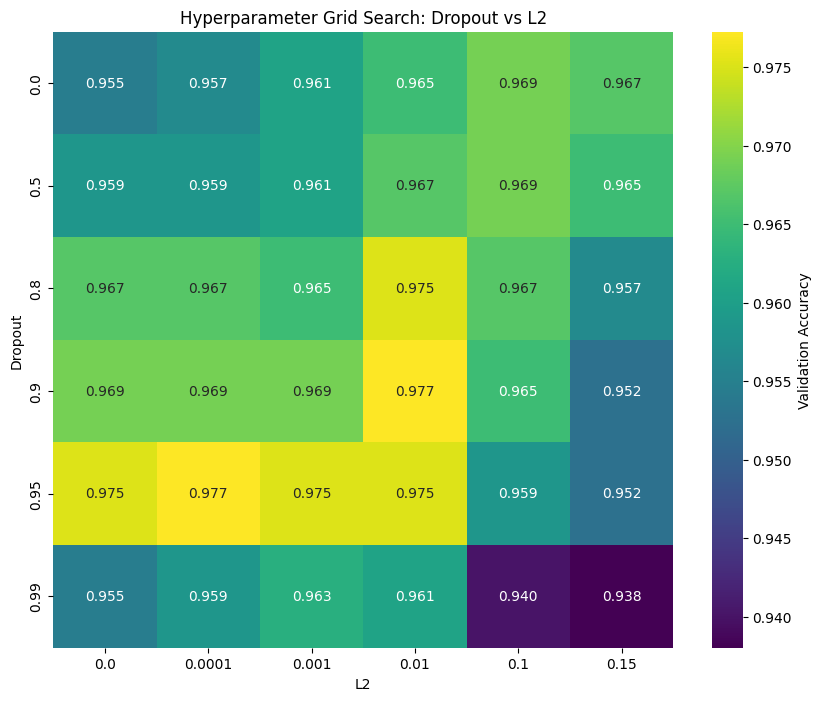

In [434]:
parameters = run_hyperparameter_search()

In [435]:
def train_and_track_history(
    dropout: float, l2: float,
    X_train: torch.Tensor, y_train: torch.Tensor,
    X_test: torch.Tensor, y_test: torch.Tensor
) -> Tuple[List[float], List[float]]:
    """
    Trains a model and returns the history of training and validation losses.
    """
    input_dim = X_train.shape[1]
    hidden_size = 128 # Large enough to overfit
    model = RegularizedANN(input_dim, hidden_size, 1, dropout_rate=dropout)
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=l2)
    
    train_losses = []
    val_losses = []
    epochs = 200
    
    for _ in range(epochs):
        # Training Step
        model.train() # Enable Dropout
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # Validation Step
        model.eval() # Disable Dropout for evaluation
        with torch.no_grad():
            y_val_pred = model(X_test)
            val_loss = criterion(y_val_pred, y_test)
            val_losses.append(val_loss.item())
            
    return train_losses, val_losses

In [436]:
def run_visual_comparison(best_dropout, best_l2) -> None:
    X_train, X_test, y_train, y_test = get_data()
    
    # Scenario 1: No regularization
    tl_base, vl_base = train_and_track_history(
        dropout=0.0, l2=0.0, 
        X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test
    )
    
    # Scenario 2: Best parameters from Grid Search    
    tl_reg, vl_reg = train_and_track_history(
        dropout=best_dropout, l2=best_l2, 
        X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test
    )

    # Visualization
    # sharey=True ensures both plots have the same Y-axis scale for direct comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Plot 1: Baseline Overfitting
    ax1.plot(tl_base, label='Train Loss', color='blue')
    ax1.plot(vl_base, label='Validation Loss', color='red', linestyle='--')
    ax1.set_title('Baseline: No Regularization\n(Classic Overfitting)')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss (BCE)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Best Regularized
    ax2.plot(tl_reg, label='Train Loss', color='blue')
    ax2.plot(vl_reg, label='Validation Loss', color='red', linestyle='--')
    ax2.set_title(f'Best Regularized Model\n(Dropout={best_dropout}, L2={best_l2})')
    ax2.set_xlabel('Epochs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

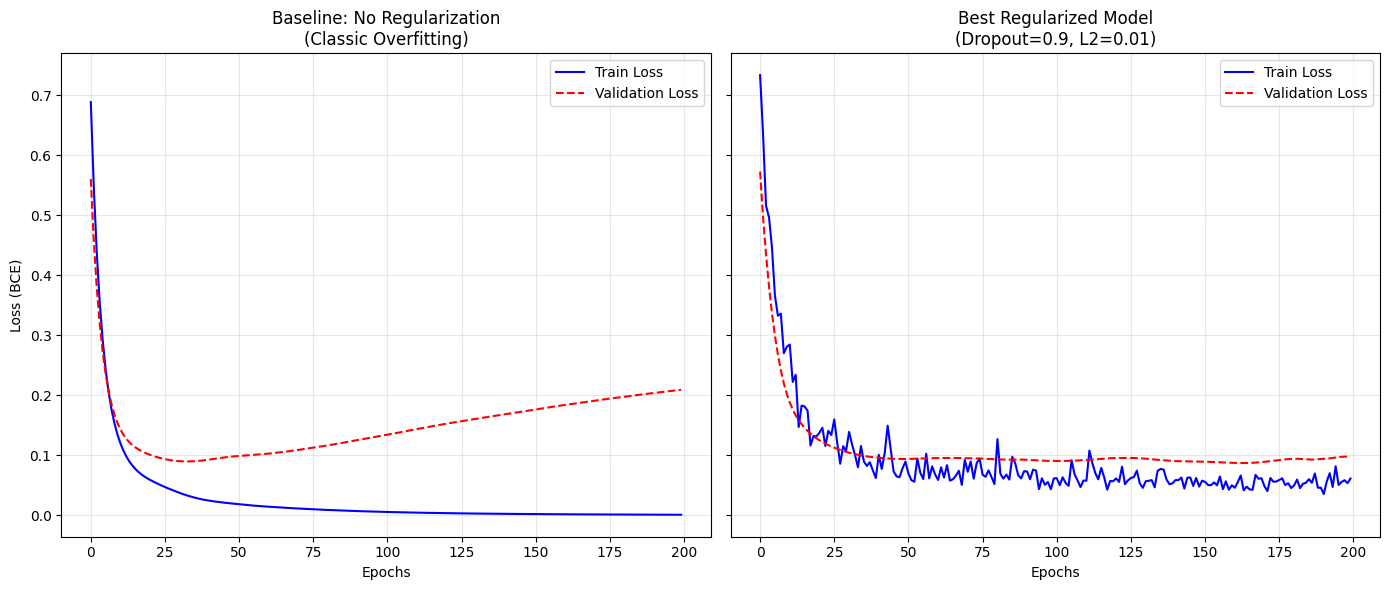

In [437]:
run_visual_comparison(parameters["Dropout"], parameters["L2"])

#### Parameter Explanation <br> L2 Regularization (Weight Decay): Penalizes large weights in the network. This forces the model to keep its decision boundaries smooth and prevents it from fitting to the noise in the training data. <br> Dropout: Randomly deactivates a percentage of neurons during each training step. This forces the network to learn robust features that do not rely on specific neurons.

#### Analysis of Regularization Results <br> Baseline: The model exhibits classic overfitting. While the training loss drops to near zero, the validation loss starts increasing significantly after epoch 25. This huge "generalization gap" means the model is useless on new data. <br> Regularized Model: The application of Dropout and L2 regularization successfully mitigated overfitting. The validation loss remains low and stable, and the gap between training and validation curves is much smaller.

#### Why was the best Dropout so high (90%)? <br> A dropout rate of 0.9 is unusually high for standard Deep Learning tasks. However, it was optimal here because of the extreme imbalance between model capacity and data size: <br>1. Tiny Dataset;<br>2. Large Model - We used a hidden layer of 128 neurons, which is massive for such a small dataset. Without a high dropout rate the 128 neurons instantly memorize the few available examples. High dropout forced this model to behave like a smaller, simpler one.